# Supply Chain Management — Exploratory Data Analysis



## 1-Setup

In [ ]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load & Validate the Data

In [2]:
#load Data
df = pd.read_csv('clean_DataCo.csv')

# Basic checks
df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 42 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Order_Type                180519 non-null  str    
 1   Order_Id                  180519 non-null  int64  
 2   Order_Item_Id             180519 non-null  int64  
 3   Order_Customer_Id         180519 non-null  int64  
 4   Order_Date                180519 non-null  str    
 5   Shipping_Date             180519 non-null  str    
 6   Actual_Shipping_Days      180519 non-null  int64  
 7   Scheduled_Shipping_Days   180519 non-null  int64  
 8   Shipping_Delay_Days       180519 non-null  int64  
 9   Delivery_Status           180519 non-null  str    
 10  Late_Delivery_Risk        180519 non-null  int64  
 11  Shipping_Mode             180519 non-null  str    
 12  Is_Date_Anomaly           180519 non-null  int64  
 13  Shipping_Performance      180519 non-null  str    
 14 

(180519, 42)

### Fix date columns

In [ ]:
# Convert Order_Date and Shipping_Date to datetime format
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print(df['Order_Date'].dtype)
df['Shipping_Date'] = pd.to_datetime(df['Shipping_Date'])
print(df['Shipping_Date'].dtype)

datetime64[ns]
datetime64[ns]


In [4]:
df.describe()

,Order_Id,Order_Item_Id,Order_Customer_Id,Order_Date,Shipping_Date,Actual_Shipping_Days,Scheduled_Shipping_Days,Shipping_Delay_Days,Late_Delivery_Risk,Is_Date_Anomaly,...,Sales,Sales_Per_Customer,Order_Item_Quantity,Order_Item_Discount,Discount_Rate,Order_Item_Product_Price,Order_Item_Total,Order_Item_Profit_Ratio,Order_Profit_Per_Order,Benefit_Per_Order
count,180519.000000,180519.000000,180519.000000,180519,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,36221.894903,90260.000000,6691.379495,2016-06-15 17:09:59.086965760,2016-06-18 21:43:33.119837696,3.497654,2.931847,0.565807,0.548291,0.182402,...,203.772096,183.107609,2.127638,20.664741,0.101668,141.232550,183.107609,0.120647,21.974989,21.974989
min,1.000000,1.000000,1.000000,2015-01-01 00:00:00,2015-01-02 00:08:00,0.000000,0.000000,-2.000000,0.000000,0.000000,...,9.990000,7.490000,1.000000,0.000000,0.000000,9.990000,7.490000,-2.750000,-4274.979980,-4274.979980
25%,18057.000000,45130.500000,3258.500000,2015-09-20 17:51:00,2015-09-25 01:54:00,2.000000,2.000000,0.000000,0.000000,0.000000,...,119.980003,104.379997,1.000000,5.400000,0.040000,50.000000,104.379997,0.080000,7.000000,7.000000
50%,36140.000000,90260.000000,6457.000000,2016-06-11 13:56:00,2016-06-15 00:50:00,3.000000,4.000000,1.000000,1.000000,0.000000,...,199.919998,163.990005,1.000000,14.000000,0.100000,59.990002,163.990005,0.270000,31.520000,31.520000
75%,54144.000000,135389.500000,9779.000000,2017-03-03 13:25:30,2017-03-08 01:49:30,5.000000,4.000000,1.000000,1.000000,0.000000,...,299.950012,247.399994,3.000000,29.990000,0.160000,199.990005,247.399994,0.360000,64.800003,64.800003
max,77204.000000,180519.000000,20757.000000,2018-12-01 23:51:00,2018-12-01 23:51:00,6.000000,4.000000,4.000000,1.000000,1.000000,...,1999.989990,1939.989990,5.000000,500.000000,0.250000,1999.989990,1939.989990,0.500000,911.799988,911.799988
std,21045.379569,52111.490959,4162.918106,NaN,NaN,1.623722,1.374449,1.490966,0.497664,0.386176,...,132.273077,120.043670,1.453451,21.800901,0.070415,139.732492,120.043670,0.466796,104.433526,104.433526


## 3. Sales & Revenue — Which categories drive the most sales?

Category_Name
Fishing                 6.929654e+06
Cleats                  4.431943e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113845e+06
Men's Footwear          2.891758e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309522e+06
Computers               6.630000e+05
Electronics             3.710346e+05
Cameras                 2.676077e+05
Garden                  2.577687e+05
Children's Clothing     2.328292e+05
Crafts                  2.233563e+05
Girls' Apparel          1.517062e+05
Women's Clothing        1.402830e+05
Accessories             1.336715e+05
Sporting Goods          1.170068e+05
Golf Gloves             1.166954e+05
Music                   1.131221e+05
Consumer Electronics    1.089913e+05
Golf Shoes              1.079980e+05
Health and Beauty       1.060805e+05
Kids' Golf Clubs        9.879758e+04
Baseball & Softball     9.405715e+04
Boxing & MMA            

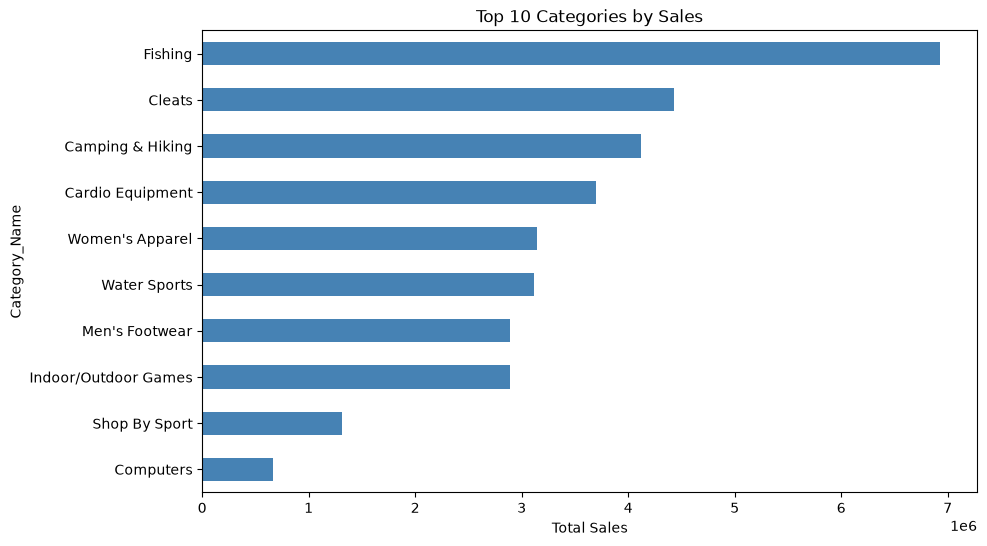

In [ ]:
# Total sales per category, sorted highest first
category_sales = df.groupby('Category_Name')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

# Visualize
plt.figure(figsize=(10,6))
category_sales.head(10).plot(kind='barh', color='steelblue')
plt.xlabel('Total Sales')
plt.title('Top 10 Categories by Sales')
plt.gca().invert_yaxis()
plt.show()

## 4. Profitability — Does the profit ranking match the sales ranking?

Category_Name
Fishing                 756220.767181
Cleats                  494636.919777
Camping & Hiking        427455.568096
Cardio Equipment        383011.098489
Women's Apparel         350421.029561
Water Sports            325146.960034
Indoor/Outdoor Games    318451.430549
Men's Footwear          311902.820204
Shop By Sport           129813.960311
Computers                69656.810171
Electronics              40891.379917
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27178.099597
Crafts                   25531.170060
Women's Clothing         19102.849931
Girls' Apparel           17288.569973
Accessories              16643.520074
Music                    14436.319923
Consumer Electronics     13223.399925
Golf Gloves              12975.490078
Baseball & Softball      12762.130067
Sporting Goods           12518.610119
Golf Shoes               12406.070143
Health and Beauty         9493.629975
Kids' Golf Clubs          9045.83989

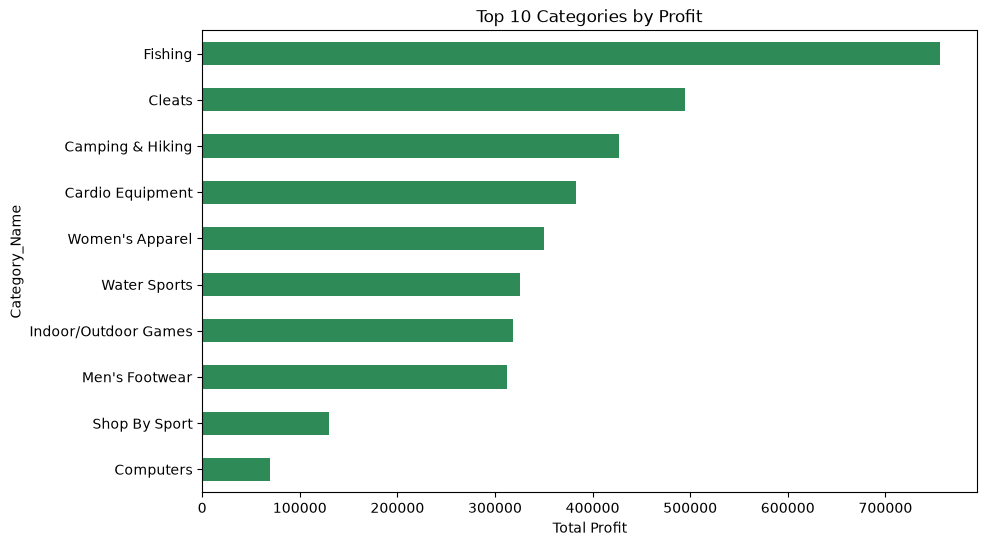

In [ ]:
# Total profit per category, sorted highest first
category_profit = df.groupby('Category_Name')['Order_Profit_Per_Order'].sum().sort_values(ascending=False)
print(category_profit)

plt.figure(figsize=(10,6))
category_profit.head(10).plot(kind='barh', color='seagreen')
plt.xlabel('Total Profit')
plt.title('Top 10 Categories by Profit')
plt.gca().invert_yaxis()
plt.show()

## 5. Does Discounting Hurt Profit?

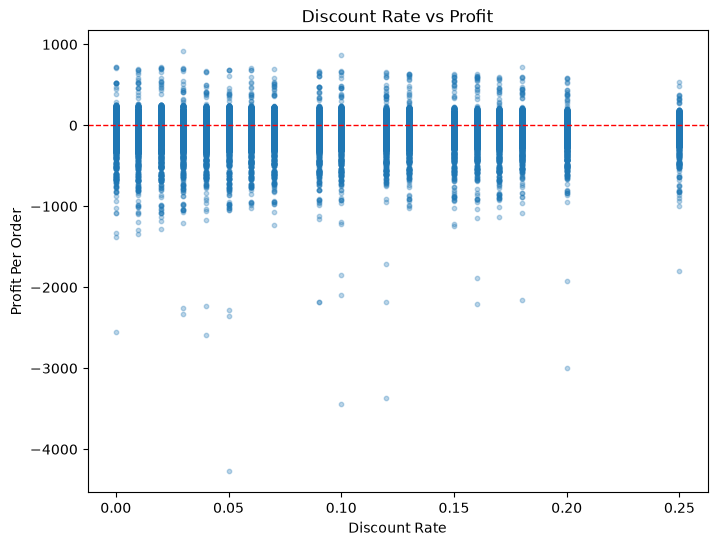

Correlation between Discount Rate and Profit: -0.018644217629801636


In [25]:
plt.figure(figsize=(8,6))
plt.scatter(df['Discount_Rate'], df['Order_Profit_Per_Order'], alpha=0.3, s=10)
plt.xlabel('Discount Rate')
plt.ylabel('Profit Per Order')
plt.title('Discount Rate vs Profit')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()

# Correlation
correlation = df['Discount_Rate'].corr(df['Order_Profit_Per_Order'])
print("Correlation between Discount Rate and Profit:", correlation)

## 6. Investigating Extreme Losses

In [ ]:
# Orders with severe losses (profit below -$1,500), sorted worst-first
extreme_loss = df[df['Order_Profit_Per_Order'] < -1500].sort_values('Order_Profit_Per_Order')
print(extreme_loss[['Order_Id', 'Category_Name', 'Product_Price', 'Order_Item_Quantity', 
                     'Discount_Rate', 'Sales', 'Order_Profit_Per_Order']].head(15))

        Order_Id      Category_Name  Product_Price  Order_Item_Quantity  \
63990      68859  Strength Training     1999.98999                    1   
169249     70533          Computers     1500.00000                    1   
8259       74556          Computers     1500.00000                    1   
126391     70760          Computers     1500.00000                    1   
33845      74508          Computers     1500.00000                    1   
12516      70560          Computers     1500.00000                    1   
84975      70537          Computers     1500.00000                    1   
11909      70845          Computers     1500.00000                    1   
97532      70753          Computers     1500.00000                    1   
82022      70683          Computers     1500.00000                    1   
35686      70718          Computers     1500.00000                    1   
38474      70565          Computers     1500.00000                    1   
18550      70660         

## 7. Category Health Check — Margin %, Not Just Totals

In [ ]:
# Aggregate sales, profit, and order count per category
category_summary = df.groupby('Category_Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Order_Profit_Per_Order', 'sum'),
    Order_Count=('Order_Id', 'count'))

#profit margin calculation
category_summary['Profit_Margin_%'] = (category_summary['Total_Profit'] / category_summary['Total_Sales']) * 100
category_summary_sorted = category_summary.sort_values('Profit_Margin_%')

# Display the top 10 categories with the lowest profit margins
print(category_summary_sorted.head(10))

                     Total_Sales  Total_Profit  Order_Count  Profit_Margin_%
Category_Name                                                               
Strength Training   54895.529541    332.310090          111         0.605350
As Seen on  TV!     20597.939964    714.429980           68         3.468454
Men's Clothing      43856.801270   2006.039970          208         4.574068
Basketball          27099.329346   1845.670003           67         6.810759
Books               12587.399969    883.010008          405         7.015031
Video Games         33310.500000   2717.519997          838         8.158148
DVDs                79395.542358   6655.430088          483         8.382624
Pet Supplies        41524.800751   3589.259959          492         8.643654
Health and Beauty  106080.483093   9493.629975          362         8.949460
Kids' Golf Clubs    98797.579239   9045.839896          384         9.155933


### Sanity check: is "Computers" actually a bad category overall?

In [ ]:
# Display the summary for the 'Computers' category
print(category_summary_sorted.loc['Computers'])

Total_Sales        663000.000000
Total_Profit        69656.810171
Order_Count           442.000000
Profit_Margin_%        10.506306
Name: Computers, dtype: float64


### Full category margin list

In [ ]:
# Display the entire category summary sorted by profit margin
pd.set_option('display.max_rows', None)
print(category_summary_sorted)

                       Total_Sales   Total_Profit  Order_Count  \
Category_Name                                                    
Strength Training     5.489553e+04     332.310090          111   
As Seen on  TV!       2.059794e+04     714.429980           68   
Men's Clothing        4.385680e+04    2006.039970          208   
Basketball            2.709933e+04    1845.670003           67   
Books                 1.258740e+04     883.010008          405   
Video Games           3.331050e+04    2717.519997          838   
DVDs                  7.939554e+04    6655.430088          483   
Pet Supplies          4.152480e+04    3589.259959          492   
Health and Beauty     1.060805e+05    9493.629975          362   
Kids' Golf Clubs      9.879758e+04    9045.839896          384   
Shop By Sport         1.309522e+06  129813.960311        10984   
Golf Apparel          3.496975e+04    3496.309983          441   
Boxing & MMA          8.520541e+04    8641.370006          423   
Cardio Equ

## 8. Delivery Performance — How much of the business is late?

Delivery_Status
Late delivery        54.829132
Advance shipping     23.040234
Shipping on time     17.835242
Shipping canceled     4.295393
Name: proportion, dtype: float64


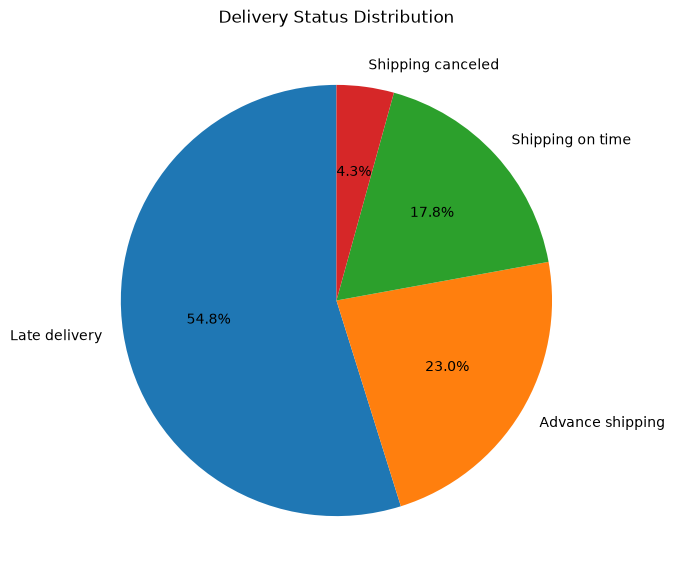

In [ ]:
# Delivery Status Distribution
delivery_status_pct = df['Delivery_Status'].value_counts(normalize=True) * 100
print(delivery_status_pct)

plt.figure(figsize=(7,7))
df['Delivery_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Delivery Status Distribution')
plt.ylabel('')
plt.show()

### Does shipping mode affect late-delivery risk?

Shipping_Mode
First Class       95.322499
Second Class      76.632781
Same Day          45.743042
Standard Class    38.071683
Name: Late_Delivery_Risk, dtype: float64


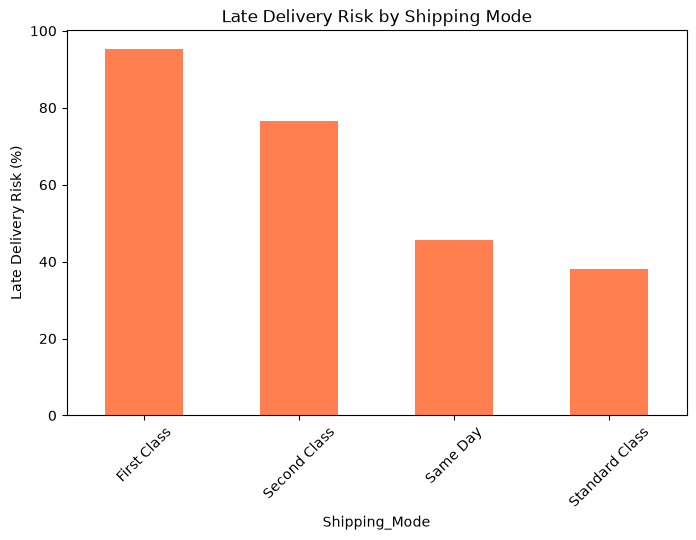

In [ ]:
# Late Delivery Risk by Shipping Mode
shipping_risk = df.groupby('Shipping_Mode')['Late_Delivery_Risk'].mean().sort_values(ascending=False) * 100
print(shipping_risk)

plt.figure(figsize=(8,5))
shipping_risk.plot(kind='bar', color='coral')
plt.ylabel('Late Delivery Risk (%)')
plt.title('Late Delivery Risk by Shipping Mode')
plt.xticks(rotation=45)
plt.show()

### Why is First Class so unreliable? Compare promised vs. actual shipping time

In [ ]:
# Compare average scheduled vs actual shipping days by shipping mode
shipping_days_compare = df.groupby('Shipping_Mode').agg(
    Avg_Scheduled_Days=('Scheduled_Shipping_Days', 'mean'),
    Avg_Actual_Days=('Actual_Shipping_Days', 'mean')
)
shipping_days_compare['Gap'] = shipping_days_compare['Avg_Actual_Days'] - shipping_days_compare['Avg_Scheduled_Days']
print(shipping_days_compare.sort_values('Gap', ascending=False))

                Avg_Scheduled_Days  Avg_Actual_Days       Gap
Shipping_Mode                                                
Second Class                   2.0         3.990828  1.990828
First Class                    1.0         2.000000  1.000000
Same Day                       0.0         0.478279  0.478279
Standard Class                 4.0         3.995907 -0.004093


### Is late delivery a regional problem, or company-wide?

Market
Europe          55.207753
Pacific Asia    55.046049
USCA            54.800574
Africa          54.589289
LATAM           54.355158
Name: Late_Delivery_Risk, dtype: float64


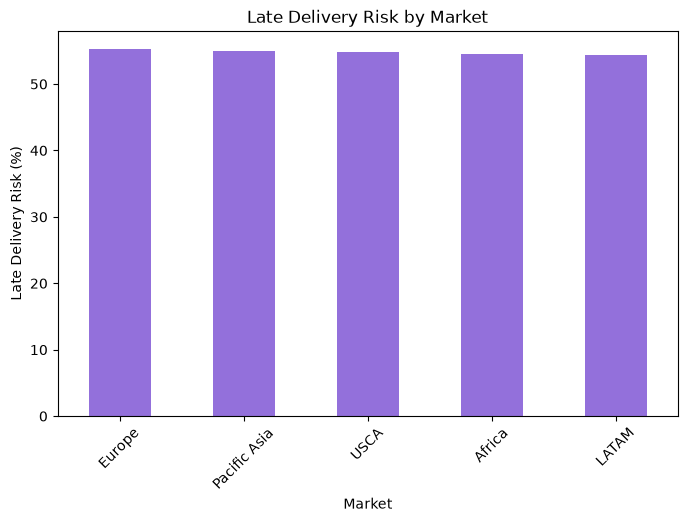

In [ ]:
# Late Delivery Risk by Market
region_late = df.groupby('Market')['Late_Delivery_Risk'].mean().sort_values(ascending=False) * 100
print(region_late)

plt.figure(figsize=(8,5))
region_late.plot(kind='bar', color='mediumpurple')
plt.ylabel('Late Delivery Risk (%)')
plt.title('Late Delivery Risk by Market')
plt.xticks(rotation=45)
plt.show()

## 9. Customer Behavior — Who are the top customers and cities?

In [ ]:
# Top 10 customers by number of orders
top_customers = df.groupby('Customer_Id')['Order_Id'].nunique().sort_values(ascending=False).head(10)
print(top_customers)
# Top 10 cities by number of orders
top_cities = df.groupby('Customer_City')['Order_Id'].nunique().sort_values(ascending=False).head(10)
print(top_cities)

Customer_Id
5654     15
12431    14
10591    14
12284    14
5283     14
3710     14
4116     13
1695     13
11645    13
5004     13
Name: Order_Id, dtype: int64
Customer_City
Caguas          24365
Chicago          1387
Brooklyn         1250
Los Angeles      1248
New York          640
Philadelphia      563
Bronx             538
San Diego         499
Houston           479
Miami             474
Name: Order_Id, dtype: int64


### Does customer segment affect order value?

In [ ]:
# Average Order Value (AOV) by Customer Segment
segment_aov = df.groupby('Customer_Segment')['Sales'].mean().sort_values(ascending=False)
print(segment_aov)

Customer_Segment
Consumer       204.224313
Corporate      203.843962
Home Office    202.337802
Name: Sales, dtype: float64


### Verifying the Caguas outlier

In [ ]:
## Customer Location Analysis for Caguas
print(df[df['Customer_City']=='Caguas']['Customer_State'].value_counts())
print(df[df['Customer_City']=='Caguas']['Customer_Country'].value_counts())

Customer_State
PR    66770
Name: count, dtype: int64
Customer_Country
Puerto Rico    66770
Name: count, dtype: int64


## 10. Investigating an Apparent Sales Decline in Late 2017/2018

In [ ]:
# Monthly sales trend
#Look at the raw monthly sales trend for the last 15 months of the dataset.
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()
print(monthly_sales.tail(15))  # last 15 months 

Order_Date
2017-10    1.250823e+06
2017-11    7.661639e+05
2017-12    7.903350e+05
2018-01    1.547773e+05
2018-02    2.860366e+04
2018-03    1.992672e+04
2018-04    1.712124e+04
2018-05    1.772420e+04
2018-06    1.622235e+04
2018-07    5.739200e+03
2018-08    5.823600e+03
2018-09    5.739200e+03
2018-10    1.507090e+04
2018-11    2.228700e+04
2018-12    2.261475e+04
Freq: M, Name: Sales, dtype: float64


In [ ]:
# Monthly orders trend
#Check monthly order count alongside sales. 
# If order volume also collapses at the same point, that points toward a data-collection issue rather than a demand-side business decline.
monthly_orders = df.groupby(df['Order_Date'].dt.to_period('M'))['Order_Id'].nunique()
print(monthly_orders.tail(15))

Order_Date
2017-10    2017
2017-11    1957
2017-12    2016
2018-01    1369
2018-02      69
2018-03      68
2018-04      69
2018-05      68
2018-06      69
2018-07      68
2018-08      69
2018-09      68
2018-10      69
2018-11      68
2018-12      69
Freq: M, Name: Order_Id, dtype: int64


### Hypothesis 1: Is this linked to the date-anomaly rows flagged in SQL?

In [ ]:
# Monthly sales trend (valid dates only)
df_valid = df[df['Is_Date_Anomaly'] == 0]

monthly_sales_valid = df_valid.groupby(df_valid['Order_Date'].dt.to_period('M'))['Sales'].sum()
print(monthly_sales_valid.tail(15))

Order_Date
2017-10    745551.849357
2017-11    398650.879520
2017-12    441270.127289
2018-01    141413.523388
2018-02     28603.660889
2018-03     19926.720581
2018-04     17121.240265
2018-05     17724.199585
2018-06     16222.349655
2018-07      4979.600090
2018-08      4051.200073
2018-09      2954.000053
2018-10      4459.100021
2018-11      2622.000000
2018-12       983.250000
Freq: M, Name: Sales, dtype: float64


### Hypothesis 2: Is 2018 simply under-represented in the dataset?

In [ ]:
# Yearly order counts
yearly_counts = df.groupby(df['Order_Date'].dt.year)['Order_Id'].count()
print(yearly_counts)

Order_Date
2015    62650
2016    62550
2017    53196
2018     2123
Name: Order_Id, dtype: int64
